### Indian cuisine based RDA diet recommendation data

In [7]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [26]:
#Indian cuisin
df = pd.read_csv(r"C:\Users\M.faisal\Desktop\ai_ml\ai_ml_projects\3Logy-NDI-AI-ML-Crash\datasets\asian_indian_recipes.csv")
df.head()

,Unnamed: 0,cuisine,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,65,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,66,indian,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,67,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,68,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,69,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2448 entries, 0 to 2447
Columns: 385 entries, Unnamed: 0 to zucchini
dtypes: int64(384), str(1)
memory usage: 7.2 MB


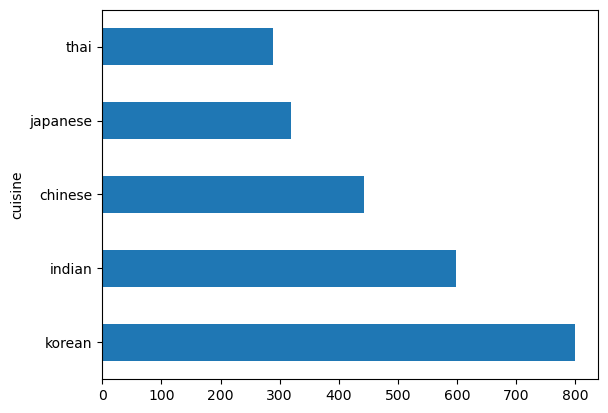

In [28]:
#Let's visualize using bar-chart to see how many cousine we have
df.cuisine.value_counts().plot.barh();

From the above you can see korean is the highest and thai is the lowest. These are all finite numbers

In [31]:
# Let's create a function called `create_ingredients` based on each cuisine.
#Let's start by creating a dataframe for each of the cuisine
thai_df = df[df["cuisine"] == "thai"]
japanese_df = df[df["cuisine"] == "japanese"]
chinese_df = df[df["cuisine"] == "chinese"]
indian_df = df[df["cuisine"] == "indian"]
korean_df = df[df["cuisine"] == "korean"]

In [32]:
#Print the shape for each cuisine
print(f"thai_df: {thai_df.shape}")
print(f"japanese_df: {japanese_df.shape}")
print(f"chinese_df: {chinese_df.shape}")
print(f"indian_df: {indian_df.shape}")
print(f"korean_df: {korean_df.shape}")

thai_df: (289, 385)
japanese_df: (320, 385)
chinese_df: (442, 385)
indian_df: (598, 385)
korean_df: (799, 385)


Let's say we've upto 5 different cuisine we can create a `df` for each one.

In [33]:
# Let's create a function called `# Let's create a function called `create_ingredients` for each cuisine to know each ingredients used for each cuisine
def create_ingredient_df(df):
    ingredient_df = df.T.drop(["cuisine", "Unnamed: 0"]).sum(axis=1).to_frame('value')
    ingredient_df = ingredient_df[(ingredient_df.T != 0).any()]
    ingredient_df = ingredient_df.sort_values(by="value", ascending=False, inplace=False)
    return ingredient_df

<Axes: >

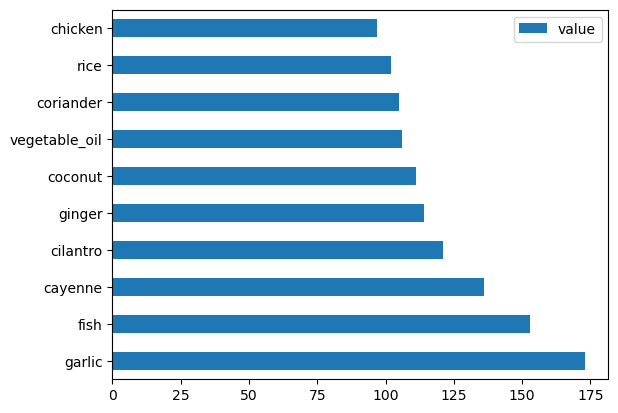

In [34]:
#Plot first 10 ingredients for thai
thai_ingredient_df = create_ingredient_df(thai_df)
thai_ingredient_df.head(10).plot.barh()

<Axes: >

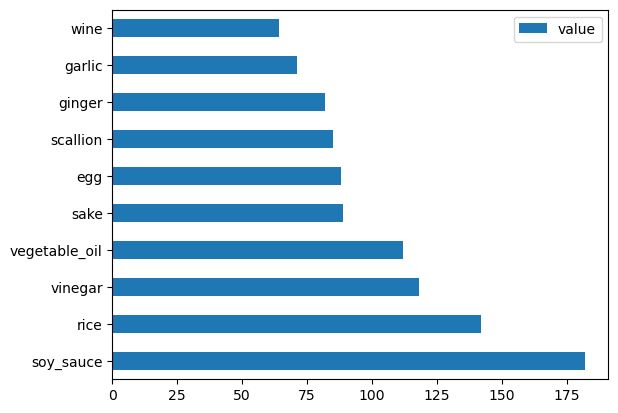

In [35]:
#Plot first 10 ingredients for japanese
japanese_ingredient_df = create_ingredient_df(japanese_df)
japanese_ingredient_df.head(10).plot.barh()

<Axes: >

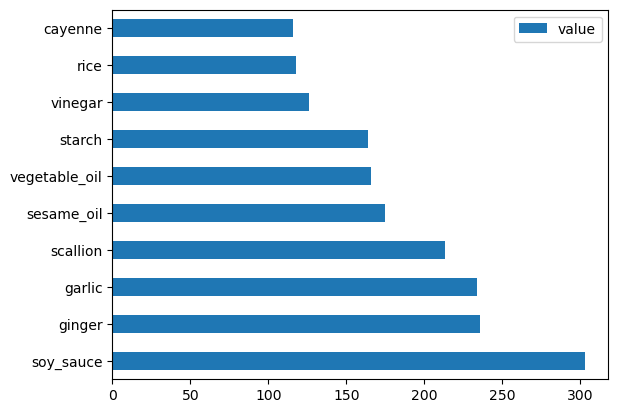

In [36]:
#Plot first 10 ingredients for chinese
chinese_ingredient_df = create_ingredient_df(chinese_df)
chinese_ingredient_df.head(10).plot.barh()

<Axes: >

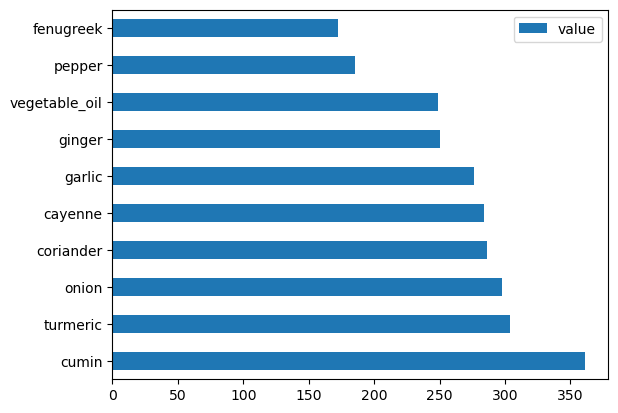

In [37]:
#Plot first 10 ingredients for indian
indian_ingredient_df = create_ingredient_df(indian_df)
indian_ingredient_df.head(10).plot.barh()

<Axes: >

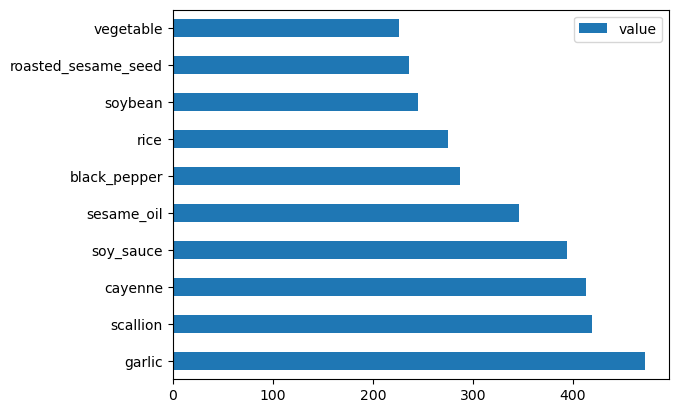

In [38]:
#Plot first 10 ingredients for indian
korean_ingredient_df = create_ingredient_df(korean_df)
korean_ingredient_df.head(10).plot.barh()

Since there are common ingredients used, we can create a feature and drop those so that it doesn't influence our model

In [41]:
feature_df = df.drop(["cuisine", "Unnamed: 0", "garlic", "ginger"], axis=1)
label_df = df.cuisine
feature_df.head()

,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,artemisia,artichoke,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [42]:
label_df

0         indian
1         indian
2         indian
3         indian
4         indian
          ...   
2443    japanese
2444    japanese
2445    japanese
2446    japanese
2447    japanese
Name: cuisine, Length: 2448, dtype: str

[`thai_df: (289, 385)`,
`japanese_df: (320, 385)`,
`chinese_df: (442, 385),`
`indian_df: (598, 385),`
`korean_df: (799, 385)`]

In [44]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-lea

In [45]:
#From the shapes above notice that our datasets have different shapes/numbers/observations, this is called `imbalanced dataset`
#To balance this we can use a technique called `SMOTE`
#Let's implement `SMOTE`
from imblearn.over_sampling import SMOTE
oversample = SMOTE()
transform_feature_df, transform_label_df = oversample.fit_resample(feature_df, label_df)

In [46]:
print(f"new label count: {transform_label_df.value_counts()}")
print(f"old label count: {label_df.value_counts()}")

new label count: cuisine
indian      799
thai        799
chinese     799
japanese    799
korean      799
Name: count, dtype: int64
old label count: cuisine
korean      799
indian      598
chinese     442
japanese    320
thai        289
Name: count, dtype: int64


In [49]:
#Let's fit the logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

In [50]:
X_train, X_test, y_train, y_test = train_test_split(transform_feature_df, transform_label_df, test_size=0.3)

In [54]:
lr = LogisticRegression(solver="lbfgs")
model = lr.fit(X_train, np.ravel(y_train))

accuracy = model.score(X_test, y_test)
print("Accuracy is {}".format(accuracy))

Accuracy is 0.7764804003336113


In [56]:
print(f"ingredients: {X_test.iloc[50][X_test.iloc[50] !=0].keys()}")
print(f"ingredients: {y_test.iloc[50]}")

ingredients: Index(['fish', 'kelp', 'sake', 'soy_sauce', 'vegetable'], dtype='str')
ingredients: japanese


In [60]:
#Lets test what our model will predict, since we want propability, we'll use `pred_prob()`
test = X_test.iloc[[50]].values.reshape(-1, 1).T   # double brackets → keeps DataFrame
proba = model.predict_proba(test)
classes = model.classes_
resultdf = pd.DataFrame(data=proba, columns=classes)
top_pred = resultdf.T.sort_values(by=[0], ascending=False)
top_pred.head()

C:\Users\M.faisal\Desktop\ai_ml\ai_ml_projects\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


,0
japanese,0.805859
korean,0.189327
chinese,0.003871
thai,0.000914
indian,0.000028


In [62]:
#Let's check the classiffication report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     chinese       0.68      0.75      0.71       232
      indian       0.90      0.87      0.88       235
    japanese       0.68      0.73      0.70       241
      korean       0.86      0.76      0.81       251
        thai       0.79      0.78      0.78       240

    accuracy                           0.78      1199
   macro avg       0.78      0.78      0.78      1199
weighted avg       0.78      0.78      0.78      1199

